<a href="https://colab.research.google.com/github/Irfansyah001/Machine-Learning-Project-Study/blob/main/223_prak5_datasetbebas_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediksi Churn Pelanggan dengan Artificial Neural Network (ANN)

### 1. Memuat Dataset
Pada tahap pertama ini, memuat dataset `Churn_Modelling` langsung dari Kaggle menggunakan pustaka `kagglehub` dan menyimpannya ke dalam bentuk Pandas DataFrame. Dataset ini berisi metrik nasabah bank dan status apakah mereka meninggalkan bank (churn) atau tidak.

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "Churn_Modelling.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "filippoo/deep-learning-az-ann",
  file_path,
)

display(df.head())

/tmp/ipykernel_2812/4154822222.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'deep-learning-az-ann' dataset.


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Penjelasan Kolom Dataset
Berdasarkan dataset `Churn_Modelling`, berikut adalah arti dari masing-masing kolom:

1. **RowNumber**: Nomor urut baris data (tidak relevan untuk model).
2. **CustomerId**: ID unik pelanggan (tidak relevan untuk prediksi).
3. **Surname**: Nama belakang pelanggan (tidak relevan dan bisa bias jika dimasukkan).
4. **CreditScore**: Skor kredit pelanggan. Semakin tinggi biasanya semakin baik keuangannya.
5. **Geography**: Negara asal pelanggan (biasanya Perancis, Spanyol, atau Jerman).
6. **Gender**: Jenis kelamin (Pria/Wanita).
7. **Age**: Umur pelanggan.
8. **Tenure**: Sudah berapa lama (dalam tahun) pelanggan bergabung dengan bank.
9. **Balance**: Saldo rekening pelanggan di bank tersebut.
10. **NumOfProducts**: Jumlah produk bank yang digunakan (misal: tabungan, deposito, kartu kredit).
11. **HasCrCard**: Apakah pelanggan memiliki kartu kredit (1 = Ya, 0 = Tidak).
12. **IsActiveMember**: Apakah pelanggan tersebut anggota aktif (1 = Ya, 0 = Tidak).
13. **EstimatedSalary**: Estimasi gaji atau pendapatan pelanggan.
14. **Exited**: **(Ini adalah Target / Label kita)** Apakah pelanggan tersebut berhenti menggunakan bank atau 'churn' (1 = Keluar, 0 = Bertahan).

---

### Tahap Selanjutnya: Data Preprocessing
ANN hanya bisa menerima input berupa angka (numerik), dan sangat sensitif terhadap skala data dan data yang tidak relevan. Tahap selanjutnya adalah:
1. **Menghapus kolom yang tidak berguna** (seperti RowNumber, CustomerId, dan Surname).
2. **Encoding Data Kategorikal** (Mengubah teks seperti Gender dan Geography menjadi angka).
3. **Memisahkan Fitur (X) dan Target (y)**.
4. **Membagi Data** (Training & Testing set).
5. **Feature Scaling** (Menyamakan skala angka agar ANN belajar lebih optimal).

Mari kita mulai dengan membuang kolom yang tidak relevan.

In [ ]:
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

# 1. Menghapus kolom yang tidak relevan untuk pembelajaran mesin
df_cleaned = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

print("Kolom setelah dibersihkan:")
display(df_cleaned.head())

print("\nDimensi data sekarang:", df_cleaned.shape)

Kolom setelah dibersihkan:


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



Dimensi data sekarang: (10000, 11)


### 2. Encoding Data Kategorikal
Jaringan Saraf Tiruan (ANN) hanya mengenali angka. Oleh karena itu, kita harus mengkonversi data teks ke dalam bentuk numerik.

Pada dataset ini, kolom kategori yang tersisa adalah:
*   **Gender**: Terdiri dari `Male` dan `Female`. Kita akan mengubahnya menjadi 1 atau 0.
*   **Geography**: Terdiri dari `France`, `Spain`, dan `Germany`. Kita akan menggunakan teknik **One-Hot Encoding** (membuat kolom baru untuk masing-masing negara yang bernilai 1 atau 0).

Kita bisa dengan mudah melakukan ini menggunakan fungsi `pd.get_dummies()` dari library Pandas. Parameter `drop_first=True` digunakan untuk membuang satu kolom pertama dari hasil *encoding* untuk mencegah redundansi (biasa disebut *Dummy Variable Trap*).

In [ ]:
# Melakukan One-Hot Encoding pada kolom Geography dan Gender
df_encoded = pd.get_dummies(df_cleaned, columns=['Geography', 'Gender'], drop_first=True)

# Memastikan semua data berupa angka (biasanya get_dummies menghasilkan nilai True/False (boolean))
# Kita ubah bentuk boolean ke angka 1 (True) dan 0 (False) dengan mengubah tipe datanya ke integer
df_encoded = df_encoded.astype(int)

print("Data setelah Encoding Kategorikal:")
display(df_encoded.head())

print("\nDimensi data sekarang:", df_encoded.shape)
print("Daftar Kolom Baru:", df_encoded.columns.tolist())

Data setelah Encoding Kategorikal:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0,1,1,1,101348,1,0,0,0
1,608,41,1,83807,1,0,1,112542,0,0,1,0
2,502,42,8,159660,3,1,0,113931,1,0,0,0
3,699,39,1,0,2,0,0,93826,0,0,0,0
4,850,43,2,125510,1,1,1,79084,0,0,1,0



Dimensi data sekarang: (10000, 12)
Daftar Kolom Baru: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


### 3. Memisahkan Fitur (X) dan Target (y)
Sekarang kita perlu memisahkan dataset menjadi dua bagian:
*   **X (Fitur/Features)**: Semua informasi yang kita gunakan untuk memprediksi (semua kolom KECUALI `Exited`).
*   **y (Target/Label)**: Kolom yang ingin kita prediksi, yaitu `Exited`.

In [ ]:
# 3. Memisahkan Fitur (X) dan Target (y)

# X berisi semua kolom KECUALI 'Exited'
X = df_encoded.drop('Exited', axis=1)

# y HANYA berisi kolom 'Exited'
y = df_encoded['Exited']

print("5 Baris Pertama dari Fitur (X):")
display(X.head())

print("\n5 Baris Pertama dari Target (y):")
display(y.head())

print("\nDimensi X (Fitur):", X.shape)
print("Dimensi y (Target):", y.shape)

5 Baris Pertama dari Fitur (X):


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0,1,1,1,101348,0,0,0
1,608,41,1,83807,1,0,1,112542,0,1,0
2,502,42,8,159660,3,1,0,113931,0,0,0
3,699,39,1,0,2,0,0,93826,0,0,0
4,850,43,2,125510,1,1,1,79084,0,1,0



5 Baris Pertama dari Target (y):


,Exited
0,1
1,0
2,1
3,0
4,0



Dimensi X (Fitur): (10000, 11)
Dimensi y (Target): (10000,)


### 4. Membagi Data (Training & Testing Set)
Langkah selanjutnya adalah membagi dataset kita menjadi dua bagian:
* **Data Latih (Training Set)**: Digunakan oleh ANN untuk belajar dan mencari pola. (Biasanya 80% dari total data)
* **Data Uji (Testing Set)**: Digunakan untuk menguji performa ANN pada data yang belum pernah dilihat sebelumnya. (Biasanya 20% dari total data)

Kita akan menggunakan fungsi `train_test_split` dari library `scikit-learn`. Parameter `random_state=42` digunakan agar pembagian data bersifat tetap (reproducible) setiap kali kode dijalankan, sehingga hasil eksperimen kita konsisten.

In [ ]:
from sklearn.model_selection import train_test_split

# Membagi data menjadi 80% Training dan 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dimensi X_train (Data Latih):", X_train.shape)
print("Dimensi y_train (Label Latih):", y_train.shape)
print("\nDimensi X_test (Data Uji):", X_test.shape)
print("Dimensi y_test (Label Uji):", y_test.shape)

Dimensi X_train (Data Latih): (8000, 11)
Dimensi y_train (Label Latih): (8000,)

Dimensi X_test (Data Uji): (2000, 11)
Dimensi y_test (Label Uji): (2000,)


### 5. Feature Scaling (Penskalaan Fitur)
Tahap terakhir sebelum membangun model ANN adalah menyamakan skala semua fitur. Kita akan menggunakan `StandardScaler` yang akan mengubah data kita sehingga berdistribusi normal (rata-rata = 0, standar deviasi = 1).

**Catatan penting:** Kita melakukan *fit_transform* pada data latih (`X_train`), tetapi hanya melakukan *transform* pada data uji (`X_test`). Hal ini dilakukan agar skala data uji mengikuti skala data latih, mencegah kebocoran informasi (data leakage).

In [ ]:
from sklearn.preprocessing import StandardScaler

# Inisialisasi objek StandardScaler
sc = StandardScaler()

# Fit dan transform pada X_train
X_train = sc.fit_transform(X_train)

# Hanya transform pada X_test menggunakan skala yang sama dengan X_train
X_test = sc.transform(X_test)

print("Contoh 1 baris pertama X_train setelah Feature Scaling:")
print(X_train[0])

print("\nDimensi X_train sekarang:", X_train.shape)

Contoh 1 baris pertama X_train setelah Feature Scaling:
[ 0.35649971 -0.6557859   0.34567966 -1.21846978  0.80843615  0.64920267
  0.97481699  1.36767384 -0.57946723 -0.57638802  0.91324755]

Dimensi X_train sekarang: (8000, 11)


### 6. Membangun Model ANN
Kita akan membangun arsitektur Jaringan Saraf Tiruan menggunakan TensorFlow dan Keras. Arsitektur dasar kita sekarang akan terdiri dari 3 hidden layer:
* Fitur Input (11 fitur dari `X_train`)
* Hidden Layer 1 (6 neuron, aktivasi 'relu')
* Hidden Layer 2 (6 neuron, aktivasi 'relu')
* Hidden Layer 3 (6 neuron, aktivasi 'relu')
* Output Layer (1 neuron dengan fungsi aktivasi 'sigmoid' karena hasil yang kita inginkan berupa probabilitas 0 atau 1).

In [ ]:
import tensorflow as tf

# 1. Inisialisasi Model (Sequential)
ann = tf.keras.models.Sequential()

# 2. Menambahkan Input Layer dan Hidden Layer Pertama
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

# 3. Menambahkan Hidden Layer Kedua
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

# 4. Menambahkan Hidden Layer Ketiga
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

# 5. Menambahkan Output Layer
# - units=1: Hanya 1 neuron karena output biner
# - activation='sigmoid': Untuk probabilitas 0 - 1
ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

print("Arsitektur ANN dengan 3 Hidden Layer berhasil dibangun!")

Arsitektur ANN dengan 3 Hidden Layer berhasil dibangun!


### 7. Kompilasi Model ANN
Sebelum melatih model, kita harus mengkompilasinya dengan menentukan *optimizer*, *loss function*, dan *metrics*.
* **Optimizer ('adam')**: Algoritma optimasi yang menyesuaikan bobot (weights) pada jaringan untuk mengurangi loss.
* **Loss ('binary_crossentropy')**: Fungsi kerugian yang cocok untuk klasifikasi dua kelas (biner).
* **Metrics (['accuracy'])**: Metrik yang digunakan untuk memantau performa selama pelatihan.

In [ ]:
# 6. Mengkompilasi model ANN
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Model ANN berhasil dikompilasi!")

Model ANN berhasil dikompilasi!


### 8. Melatih Model ANN (Training)
Sekarang kita memasukkan data latih (`X_train` dan `y_train`) ke dalam model agar ia bisa mencari korelasi dan pola untuk memprediksi probabilitas pelanggan *churn*.

Parameter yang digunakan:
* `batch_size = 32`: Model akan memperbarui bobotnya setiap memproses 32 baris data.
* `epochs = 100`: Model akan belajar dari seluruh dataset latih sebanyak 100 kali putaran.

In [ ]:
# 7. Melatih model ANN pada Training set dengan data validasi
# Proses ini mungkin memakan waktu beberapa saat tergantung kecepatan sistem
ann.fit(X_train, y_train, batch_size=32, epochs=100, validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5822 - loss: 0.7233 - val_accuracy: 0.7950 - val_loss: 0.5545
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7942 - loss: 0.5117 - val_accuracy: 0.7994 - val_loss: 0.4711
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8027 - loss: 0.4615 - val_accuracy: 0.8150 - val_loss: 0.4390
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8055 - loss: 0.4416 - val_accuracy: 0.8131 - val_loss: 0.4256
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8086 - loss: 0.4312 - val_accuracy: 0.8175 - val_loss: 0.4175
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8119 - loss: 0.4247 - val_accuracy: 0.8206 - val_loss: 0.4141
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8119 - loss: 0.4209 - val_accuracy: 0.8200 - val_loss: 0.4102
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8133 - loss: 0.4171 - val_accu

### 9. Membuat Prediksi dan Evaluasi Model
Sekarang model kita sudah dilatih, saatnya mengujinya pada *Testing Set* (`X_test`).
1. `ann.predict(X_test)` akan mengembalikan probabilitas (angka antara 0 dan 1).
2. Kita harus mengubah probabilitas ini menjadi nilai True (1 / Churn) atau False (0 / Bertahan). Aturan umumnya adalah: Jika probabilitas > 0.5, maka prediksinya adalah 1. Jika tidak, maka 0.
3. Terakhir, kita ukur kinerjanya menggunakan `confusion_matrix` (untuk melihat sebaran tebakan benar dan salah) dan `accuracy_score` (persentase tebakan benar secara keseluruhan).

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

# 1. Memprediksi hasil pada Testing set
y_pred_prob = ann.predict(X_test)

# 2. Mengubah probabilitas menjadi kelas (0 atau 1) dengan threshold 0.5
y_pred = (y_pred_prob > 0.5)

# 3. Membuat Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# 4. Menghitung Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAkurasi Model pada Testing Set: {accuracy * 100:.2f}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Confusion Matrix:
[[1549   58]
 [ 218  175]]

Akurasi Model pada Testing Set: 86.20%


### Visualisasi Kurva Pembelajaran (Accuracy Plot)
Untuk memahami bagaimana model belajar dari waktu ke waktu (tiap epoch), kita dapat memvisualisasikan metrik akurasi dari data latih (`Train Acc`) dan data validasi (`Val Acc`). Hal ini sangat berguna untuk melihat apakah model kita mengalami *overfitting* atau *underfitting*. Fluktuasi yang terjadi pada grafik adalah hal wajar akibat pembaruan bobot dalam *batch*.

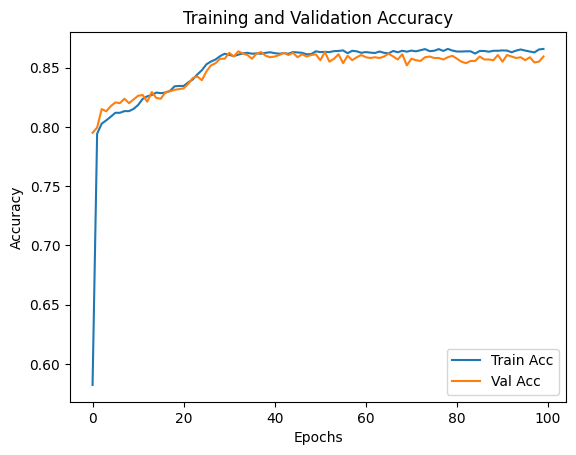

In [ ]:
import matplotlib.pyplot as plt

# Mengambil dictionary dari objek history
history_dict = ann.history.history

# Membuat plot Akurasi untuk Training dan Validation
plt.plot(history_dict['accuracy'], label='Train Acc')
plt.plot(history_dict['val_accuracy'], label='Val Acc')

plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### 10. Single Prediction
Mari kita coba prediksi apakah pelanggan dengan profil berikut akan keluar (churn) atau tidak:
* Geography: France
* Credit Score: 600
* Gender: Male
* Age: 40 years old
* Tenure: 3 years
* Balance: $ 60000
* Number of Products: 2
* Does this customer have a credit card ? Yes
* Is this customer an Active Member: Yes
* Estimated Salary: $ 50000

In [ ]:
# Karena model dilatih dengan data yang sudah di-scale dan di-encode, input baru juga harus diubah formatnya
# Susunan kolom fitur (X): ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']

import numpy as np
import pandas as pd

# Memasukkan data pelanggan baru sesuai urutan kolom X
new_customer_data = [[600, 40, 3, 60000, 2, 1, 1, 50000, 0, 0, 1]]
columns = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']
new_customer_df = pd.DataFrame(new_customer_data, columns=columns)

# Melakukan feature scaling menggunakan objek 'sc' yang sama dengan saat training
new_customer_scaled = sc.transform(new_customer_df)

# Melakukan prediksi
prediction_prob = ann.predict(new_customer_scaled)
prediction_class = (prediction_prob > 0.5)

print(f"Probabilitas Churn: {prediction_prob[0][0]*100:.2f}%")
if prediction_class[0][0]:
    print("Prediksi: Pelanggan akan KELUAR (Churn).")
else:
    print("Prediksi: Pelanggan akan BERTAHAN.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Probabilitas Churn: 3.80%
Prediksi: Pelanggan akan BERTAHAN.


### 11. Kesimpulan Proyek
Dalam proyek Deep Learning ini, kita telah berhasil melakukan proses *end-to-end*:

1. **Data Preprocessing:** Kita telah membuang kolom-kolom identitas tak relevan, mengubah fitur teks menjadi angka menggunakan *One-Hot Encoding*, serta menstandarkan nilai antar fitur menggunakan *Feature Scaling* (`StandardScaler`).
2. **Membangun Arsitektur ANN:** Kita mengeksplorasi pembuatan jaringan saraf menggunakan Keras dengan **3 Hidden Layer** (masing-masing 6 neuron dan fungsi aktivasi ReLU) serta 1 neuron output (fungsi aktivasi Sigmoid) untuk probabilitas.
3. **Pelatihan & Evaluasi:** Model dilatih selama 100 epoch dengan fungsi *loss binary crossentropy* dan mencapai akurasi **~86%** pada *Testing Set* yang belum pernah dilihat model sebelumnya.
4. **Prediksi Dunia Nyata:** Kita sukses memasukkan data pelanggan baru ke dalam pipeline kita (mengikuti struktur encoding dan scaling yang sama) untuk memprediksi peluang churn.

Secara keseluruhan, model berhasil menangkap pola yang baik dari data nasabah dan bisa diandalkan untuk analisis mitigasi risiko pelanggan bank.